# CFL Pipeline Example on MNIST Dataset 
-----------------
This notebook will show how to run a basic experiment using the `cfl` package. The experiment aims to show how CFL can aggregate hand-drawn digits into groups of numbers based on some effect variable.

Contents 
- Experiment Setup
- Data Generation
- CFL Pipeline
- Visualizing Results
- Quantifying Error


## Experiment Setup

This is a demonstration of the CFL pipeline on the MNIST dataset. We generate data in the following way:

Consider the dataset, which are are images $x$ from 0 to 9. The true macrovariables $X$ are states $A, B, C$ for which numbers 0-3 are in class $A$, 4-6 in class $B$, and 7-9 in class $C$. For some number $x$ from the data set, we have affect variable $Y\in \{\alpha, \beta\}$, which obey the following distribution.

$P(\alpha | A) = 0.95,P(\beta | A) =0$

$P(\alpha | B) =0,P(\beta | B) =0.95$

$P(\alpha | C) =0.5,P(\beta | C) =0.5$

Below we have a visual representation of cause and effect macrovariables. 

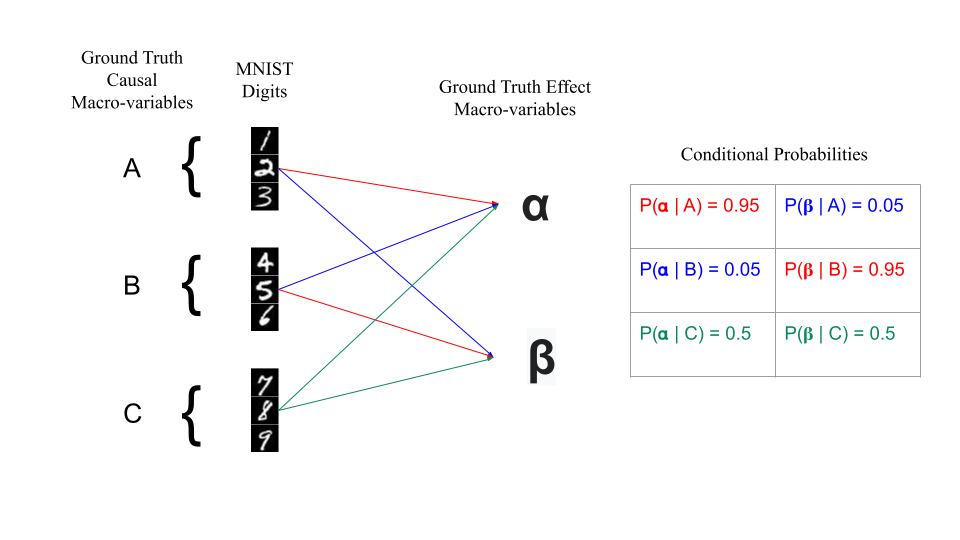

Above we see the setup for a pair of cause and effect variables that use the MNIST data . We have as input MNIST digits from zero to nine. In this set-up, the digits are grouped into three causal classes, with digits one through three, four through six, and seven through nine belonging to causal classes A, B, and C respectively. These classes dictate the probability of observing effect variables alpha versus beta. As can be seen in the diagram, class A is primarily associated with alpha and class B is primarily associated with beta, with slight deviations. Class C will produce either alpha or beta with equal probabilities. Thus, from raw image data, CFL must be able to discern the macro-variable classes A, B, C that “cause” an outcome value of alpha or beta.


## Data Generation
We first import the MNIST training and test sets. Note that in our example, we will be discarding 0 images. Also to enhance learning, we shall scale the intensities down to a [0,1] range.

In [1]:
from tensorflow.keras.datasets import mnist
import numpy as np

(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

# Keep only data 1-9

X_train = X_train[Y_train != 0]
Y_train = Y_train[Y_train != 0]

X_test = X_test[Y_test != 0]
Y_test = Y_test[Y_test != 0]


In [2]:
print('MNIST Dataset Shape:')
print('X_train: ' + str(X_train.shape))
print('Y_train: ' + str(Y_train.shape))
print('X_test:  '  + str(X_test.shape))
print('Y_test:  '  + str(Y_test.shape))

MNIST Dataset Shape:
X_train: (54077, 28, 28)
Y_train: (54077,)
X_test:  (9020, 28, 28)
Y_test:  (9020,)


In [3]:
# We must divide convert the image values from [0, 255] to [0, 1] to speed up training

MAX_RGB = 255

X_train = np.true_divide(X_train, MAX_RGB)
X_test = np.true_divide(X_test, MAX_RGB)

We shall now generate effect classes alpha and beta according to causal classes A, B, C, and their correpsonding distributions. Refer to the setup described previously.

In [4]:
from cfl import util
import random

# Generate target (Y) data. Here 'a' and 'b' are represent alpha and beta

targets = ['a', 'b']
class_A = [1, 7, 4]
class_B = [2, 3, 5]
class_C = [6, 8, 9]
distributions = [[0.95, 0.05], [0.05, 0.95], [0.5, 0.5]]

def get_distribution(val):
    if val in class_A:
        return distributions[0]
    elif val in class_B:
        return distributions[1]
    else:
        return distributions[2]

def generate_target(data):
    target = []
    for val in data:
        target += (random.choices(targets, get_distribution(val)))
    return np.array(target)

## CFL Pipeline

Some manipulation is required to fit the neural network. Causal variables are flattened into a single vector and effect variables are one-hot-encoded into distinct categorical classes.

In [5]:
#reformat X into the right shape for the neural net 
X = np.expand_dims(X_train, -1)
Y = util.data_processing.one_hot_encode(generate_target(Y_train), targets)
print(X.shape[1:])

(28, 28, 1)



Now we define the parameters of CFL. We must provide three dictionaries: information about the dataset, parameters for the CNN, and clustering parameters.

In [6]:
#import standard pacakges 
import numpy as np #needed for reshaping arrays 
import matplotlib.pyplot as plt #for rendering plots


# you can also import specific files, functions, or classes
# into the local namespace 
# from cfl.cfl_wrapper import make_CFL
# from cfl.save.experiment_saver import ExperimentSaver

from cfl.experiment import Experiment
from cfl.dataset import Dataset

# or rename modules for brevity 
from cfl.visualization_methods import visual_bars_vis as vis

In [7]:

data_info = { 'X_dims' : X.shape, 
              'Y_dims' : Y.shape, 
              'Y_type' : 'categorical' } 

# CDE parameters
CNN_params = { # parameters for model creation
                'filters'         : [32, 16],
                'input_shape'     : (28, 28, 1),
                'kernel_size'     : [(3, 3)] *2,
                'pool_size'       : [(2, 2)] *2,
                'padding'         : ['same'] *2,
                'conv_activation' : ['softmax', 'softmax'],
                'dense_units'     : 500,
                'dense_activation' : 'softmax',
                'output_activation': 'softmax',
    
                # parameters for training
                    'batch_size'  : 128,
                    'n_epochs'    : 30,
                    'optimizer'   : 'adam',
                    'opt_config'  : {},
                    'verbose'     : 2,
                    'weights_path': None,
                    'loss'        : 'categorical_crossentropy',
#     'mean_squared_error'
                    'show_plot'   : True,
                    'standardize' : False,
                    'best'        : True,
    
    
#                 # parameters for training
#                 'batch_size'  : 16,
#                 'optimizer'   : 'adam',
#                 'n_epochs'    : 10,
#                 'opt_config'  : {'lr': 1e-3}, 
#                 'verbose'     : True,
#                 'dense_units' : [784, 200, 80,  2],
#                 'activations' : ['relu', 'relu', 'relu', 'softmax'],
#                 'dropouts'    : [0.5, 0.2, 0.2, 0],
#                 'standardize' : False,
              }

cluster_params = {  'n_Xclusters' : 3,
                    'n_Yclusters' : 2,
                 }   
                            
block_names = ['CondExpCNN', 'Kmeans']
block_params = [CNN_params, cluster_params]

my_exp = Experiment(X_train=X, Y_train=Y, data_info=data_info, block_names=block_names, block_params=block_params, blocks=None, results_path='results/mnist')

my_exp.blocks[0].model.summary()

All results from this run will be saved to results/mnist/experiment0054
name not specified in input, defaulting to CondExpCNN
verbose specified but not used by Kmeans
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 28, 28, 32)        320       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 14, 14, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 14, 14, 16)        4624      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 7, 7, 16)          0         
_________________________________________________________________
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)        

Training CFL pipeline.
Epoch 1/30
317/317 - 21s - loss: 0.6930 - val_loss: 0.6933
Epoch 2/30
317/317 - 21s - loss: 0.6092 - val_loss: 0.5183
Epoch 3/30
317/317 - 20s - loss: 0.4972 - val_loss: 0.4792
Epoch 4/30
317/317 - 22s - loss: 0.4635 - val_loss: 0.4549
Epoch 5/30
317/317 - 21s - loss: 0.4428 - val_loss: 0.4357
Epoch 6/30
317/317 - 21s - loss: 0.4245 - val_loss: 0.4239
Epoch 7/30
317/317 - 20s - loss: 0.4129 - val_loss: 0.4139
Epoch 8/30
317/317 - 22s - loss: 0.4076 - val_loss: 0.4103
Epoch 9/30
317/317 - 22s - loss: 0.4020 - val_loss: 0.4047
Epoch 10/30
317/317 - 21s - loss: 0.3984 - val_loss: 0.4033
Epoch 11/30
317/317 - 22s - loss: 0.3958 - val_loss: 0.4004
Epoch 12/30
317/317 - 20s - loss: 0.3937 - val_loss: 0.3994
Epoch 13/30
317/317 - 20s - loss: 0.3922 - val_loss: 0.3985
Epoch 14/30
317/317 - 20s - loss: 0.3911 - val_loss: 0.3978
Epoch 15/30
317/317 - 20s - loss: 0.3894 - val_loss: 0.3958
Epoch 16/30
317/317 - 20s - loss: 0.3873 - val_loss: 0.3949
Epoch 17/30
317/317 - 21s 

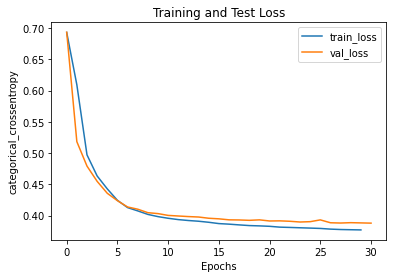

Loading parameters from  tmp_checkpoints/best_weights
Saving parameters to  results/mnist/experiment0054/trained_blocks/CondExpCNN


In [8]:
results = my_exp.train()

Now that our conditional density estimator is trained, we can make predictions on a test dataset. We shall generate the test set in the same manner as the training set before.

In [9]:
# Using previous functions to create test data

# X_new = np.reshape(X_test, (X_test.shape[0], X_test.shape[1] * X_test.shape[2]))

X_new = np.expand_dims(X_test, -1)

Y_truth = generate_target(Y_test)
Y_new = util.data_processing.one_hot_encode(Y_truth, targets)

In [10]:
# Using saved experiment, we will make predictions on test data set

my_exp.add_dataset(X=X_new, Y=Y_new, dataset_name='dataset_test')
results_new = my_exp.predict('dataset_test')


## Visualizing Results

Below we visualize predictions on a few examples. These classes should resemble the cause and effect classes previously described.

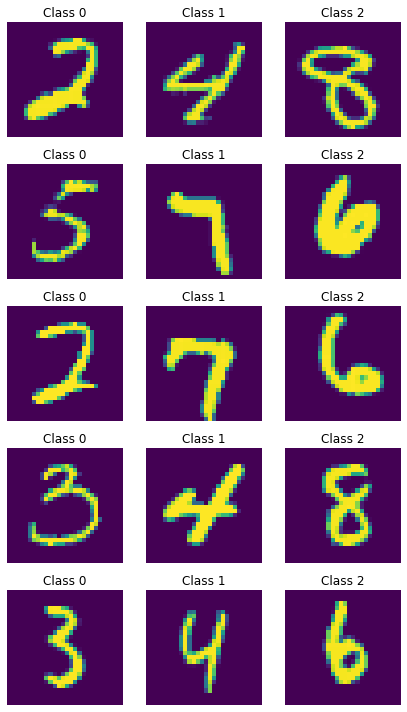

In [11]:
# Visualization X classes

vis.viewImagesAndLabels(X_test, im_shape=(10,10), n_examples=5, x_lbls=results_new['Kmeans']['x_lbls'])

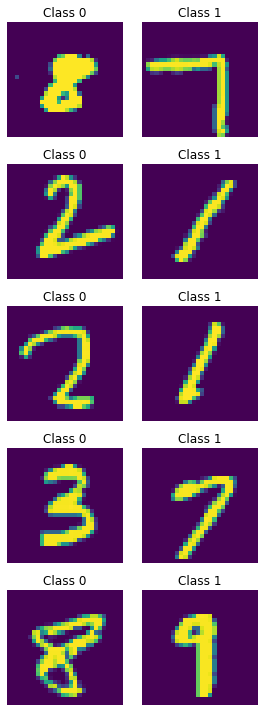

In [12]:
# Visualization Y classes

vis.viewImagesAndLabels(X_test, im_shape=(10,10), n_examples=5, x_lbls=results_new['Kmeans']['y_lbls'])

In [13]:
# from cfl.cluster_methods.kmeans import KMeans

# # create a number of Kmeans objects with different Ks 
# k_range = range(2, 8)

# kmeans_l = []
# for n_clusters in k_range:
#     params = {'n_Xclusters': n_clusters, 'n_Yclusters': 2} 
#     kmeans_obj = KMeans('Kmeans', data_info, params, random_state=143)
#     kmeans_l.append(kmeans_obj)

# data = Dataset(X_new, Y_new)

# # trained all the data on the kmeans
# x_lbls_L = []
# for kmeans_obj in kmeans_l: 
#     cluster_results = kmeans_obj.train(data, results_new['CondExpCNN'])
#     x_lbls_L.append(cluster_results['x_lbls'])

In [14]:
# from cfl.visualization_methods import clustering_to_sankey as sk

# import plotly.graph_objects as go

# link, label = sk.convert_lbls_to_sankey_nodes(x_lbls_L)
# # plot
# fig = go.Figure(data=
#           [go.Sankey(node = dict(pad = 15, thickness=20, label = label, color =  "blue"),
#                      link = link)])
    
# fig.update_layout(title_text="MNIST Clustering, with 2 to 7 Clusters", font_size=10)
# fig.show()


Below we have four histograms. A CFL conditional density estimator (CDE) will take as input an image, and it will output the probability of belonging to a class. Below we fix this class to be alpha (also showing beta would be redundant because it is the complement). For every plot, the x-axis represents the the probability of belonging to class alpha, and the y-axis is the number of images that the CDE assigns some probability.


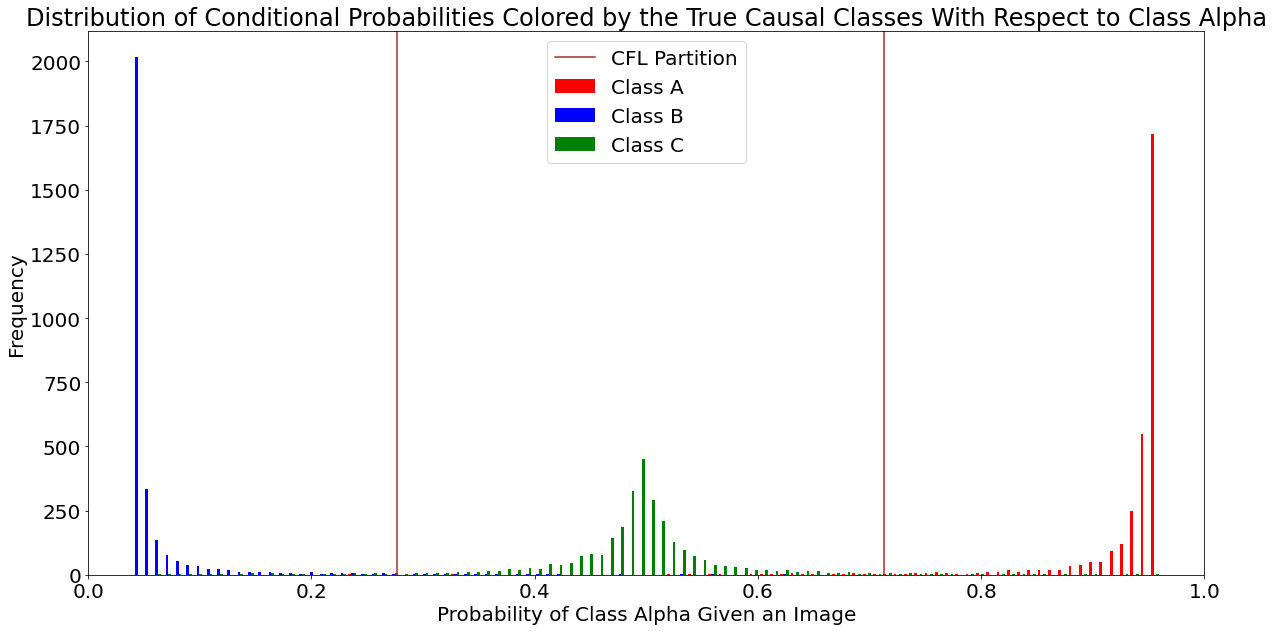

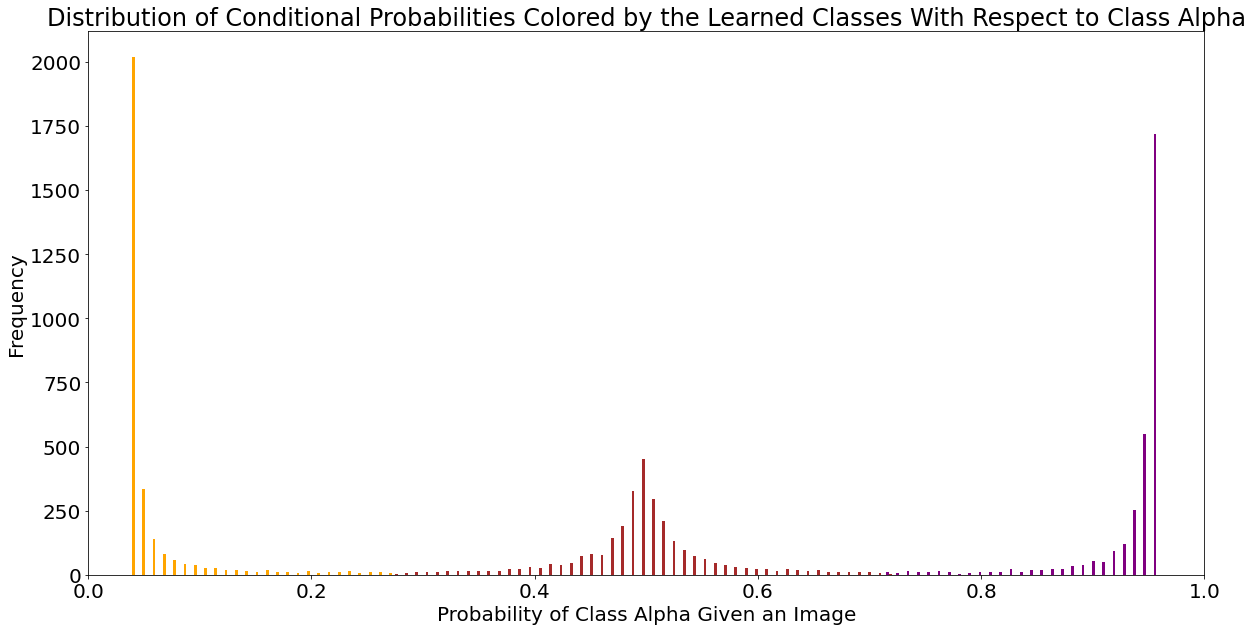

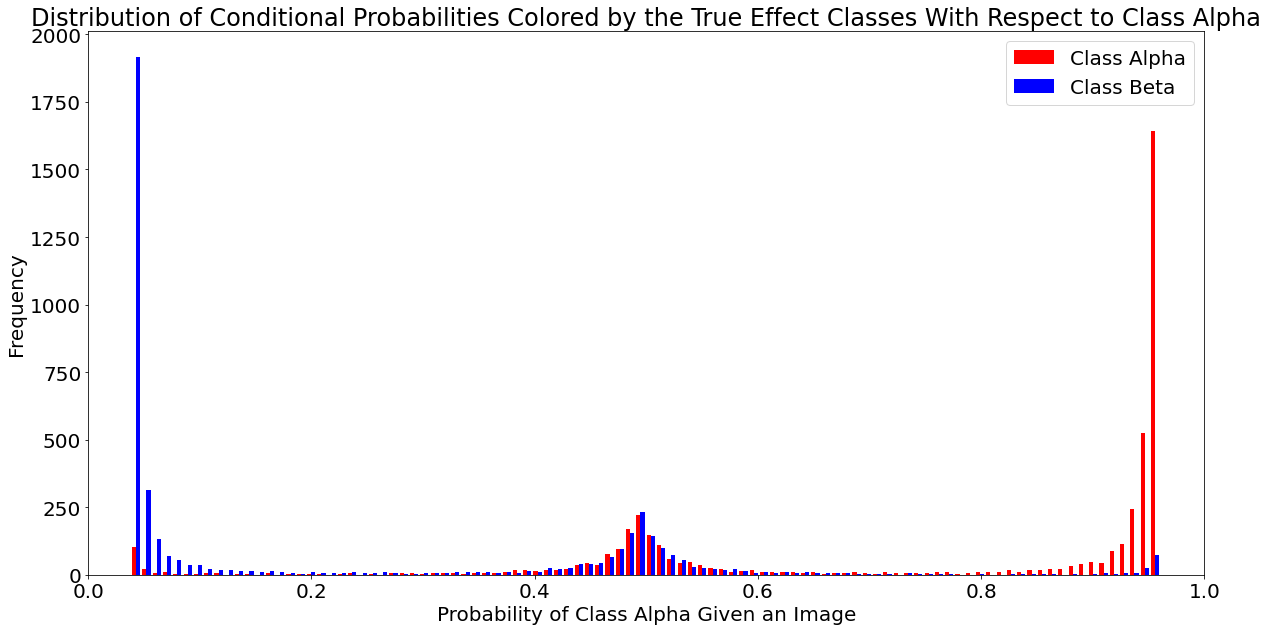

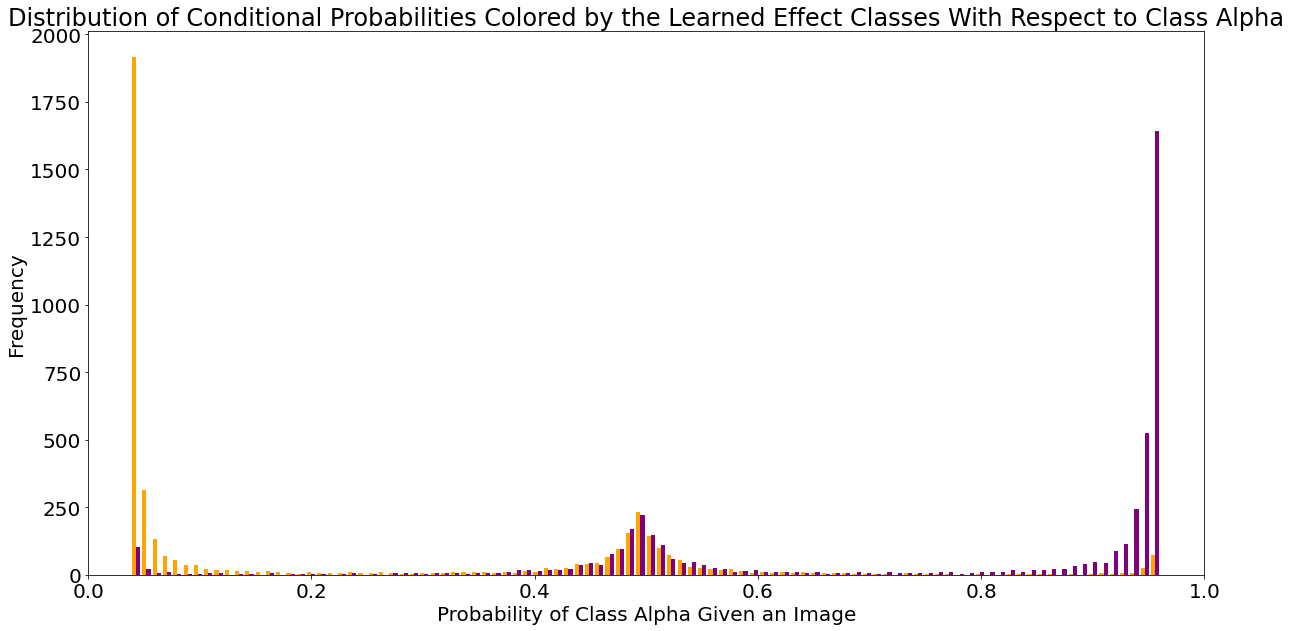

In [51]:
import matplotlib.patches as mpatches

# create a scatter plot showing conditional expectation of the target, as predicted by the CDE, 
# colored by ground truth class  

# def get_affect_colors(truth):
#     colors = []
#     for category in truth:
#         if category == 'a':
#             colors.append('red')
#         else:
#             colors.append('blue')
#     return np.array(colors)

# def learned_affect_colors(truth):
#     colors = []
#     for category in truth:
#         if category == 0:
#             colors.append('fuchsia')
#         elif category == 1:
#             colors.append('olive')
#         else: 
#             colors.append('cyan')
#     return np.array(colors)

# def get_cause_colors(truth):
#     colors = []
#     for val in truth:
#         if val <= 3:
#             colors.append('red')
#         elif val <= 6:
#             colors.append('blue')
#         else:
#             colors.append('green')
#     return np.array(colors)

# def get_result_colors(result):
#     colors = []
#     for val in result:
#         if val == 0:
#             colors.append('orange')
#         elif val == 1:
#             colors.append('purple')
#         elif val == 2:
#             colors.append('brown')
#     return np.array(colors)

def partition(probs, truth, truth_variables):
    result = []
    for var in truth_variables:
        result.append(probs[np.isin(truth, var)])
    return np.array(result, dtype=object)
        
def partition_cause_class(probs, truth):
    return partition(probs, truth, [class_A, class_B, class_C])

def partition_learned_cause(probs, truth):
    return partition(probs, truth, [[0],[1],[2]])

def partition_effect_class(probs, truth):
    return partition(probs, truth, [['a'],['b']])

def partition_learned_effect(probs, truth):
    return partition(probs, truth, [[0],[1]])
    

# def plot(n_points, data_idx, point_size, colors):
#     truth = Y_new
#     fig = plt.figure()
#     plot_idx = range(n_points)
#     colors = colors[plot_idx]
#     pyx = results_new['CondExpCNN']['pyx']
#     plt.scatter(plot_idx, pyx[plot_idx][:, data_idx], c=colors, s = point_size)
#     classes = util.data_processing.one_hot_encode(np.array(targets), targets) 
#     titles = ['Alpha', 'Beta']
#     plt.xlabel('Samples')
#     plt.ylabel('Probability of Y = {} Given X'.format(titles[data_idx]))

def patch(color):
    return mpatches.Patch(color=color)

# affect_legend = ['Class Alpha', 'Class Beta']
# cause_legend = ['Class A', 'Class B', 'Class C']

# affect_patches = [patch('red'), patch('blue')]
# cause_patches = [patch('red'), patch('blue'), patch('green')]


# learned_affect_patches = [patch('orange'), patch('seagreen')]

# fig = plt.figure()
# plot(9020, 0, 1, get_affect_colors(Y_truth))
# plt.legend(affect_patches, affect_legend, bbox_to_anchor=(1.05, 1))
# plt.title('Learned Probabilities Colored by the True Causal Classes')


# plot(9020, 0, 1, learned_affect_colors(results_new['Kmeans']['y_lbls']))
# # plt.legend(affect_patches, affect_legend, bbox_to_anchor=(1.05, 1))
# plt.title('Learned Probabilities Colored by the Learned Causal Classes')


# plt.figtext(0.5, -0.1, 'Actual classes (top), CFL output classes (bottom)', wrap=True, horizontalalignment='center', fontsize=12)

# fig = plt.figure()
# plot(9020, 0, 1, get_cause_colors(Y_test))
# plt.legend(cause_patches, cause_legend, bbox_to_anchor=(1.05, 1))
# plt.title('Learned Probabilities Colored by the Learned Affect Classes')
 
# plot(9020, 0, 1, learned_affect_colors(results_new['Kmeans']['x_lbls']))
# plt.title('Learned Probabilities Colored by the Learned Affect Classes')

# plt.figtext(0.5, -0.1, 'Actual classes (top), CFL output classes (bottom)', wrap=True, horizontalalignment='center', fontsize=12)

pyx = results_new['CondExpCNN']['pyx']

# print('Minimum: ', min(pyx[:][:, 0]))
# print('Maximum: ', max(pyx[:][:, 0]))

n_bins = 100
cause_colors = ['red', 'blue', 'green']
plt.rc('font', size=20)
plt.figure(figsize=(20,10))
plt.xlabel('Probability of Class Alpha Given an Image')
plt.ylabel('Frequency')
plt.title('Distribution of Conditional Probabilities Colored by the True Causal Classes With Respect to Class Alpha')

save_learned = partition_learned_cause(pyx[:][:, 0], results_new['Kmeans']['x_lbls'])
maxes = sorted([max(x) for x in save_learned])
mins = sorted([min(x) for x in save_learned])
plt.axvline(x=maxes[1],color='brown')
plt.hist(partition_cause_class(pyx[:][:, 0], Y_test) , n_bins, histtype='bar', color=cause_colors, label=cause_colors)


plt.legend(['CFL Partition', 'Class A', 'Class B', 'Class C'])
plt.axvline(x=mins[1], color='brown')
plt.xlim(0,1)


plt.figure(figsize=(20,10))
plt.title('Distribution of Conditional Probabilities Colored by the Learned Classes With Respect to Class Alpha')
plt.xlabel('Probability of Class Alpha Given an Image')
plt.ylabel('Frequency')
cause_colors = ['orange', 'purple', 'brown']
plt.hist(save_learned, n_bins, histtype='bar', color=cause_colors, label=cause_colors)
plt.xlim(0,1)


plt.figure(figsize=(20,10))
plt.title('Distribution of Conditional Probabilities Colored by the True Effect Classes With Respect to Class Alpha')
plt.xlabel('Probability of Class Alpha Given an Image')
plt.ylabel('Frequency')
effect_colors = ['red', 'blue']
plt.hist(partition_effect_class(pyx[:][:, 0], Y_truth), n_bins, histtype='bar', color=effect_colors, label=effect_colors)
plt.xlim(0,1)
plt.legend(['Class Alpha', 'Class Beta'])


plt.figure(figsize=(20,10))
plt.title('Distribution of Conditional Probabilities Colored by the Learned Effect Classes With Respect to Class Alpha')
plt.xlabel('Probability of Class Alpha Given an Image')
plt.ylabel('Frequency')
cause_colors = ['orange', 'purple']
plt.hist(partition_learned_effect(pyx[:][:, 0], results_new['Kmeans']['y_lbls']), n_bins, histtype='bar', color=cause_colors, label=cause_colors)
plt.xlim(0,1);


The difference between each histogram above is the coloring. Each histogram is a stacked histogram with different colors at each interval. The first histogram is colored by the true causal classes, while the second is colored by the learned causal classes. Similarly, the third histogram is colored by the true effect classes, while the fourth histogram is colored by learned affect classes. Comparing histograms of the ground truth with learned classes shows the how successful CFL is in partitioning the data.

## Quantifying Error

As we can see in the above graphs, CFL partitions the dataset accurately but not perfectly. We define two forms of error to quantify the success of CFL: distribution error and classification error. 

Observe that had CFL found the causal classes perfectly, we would expect three vertical bars in the histogram positioned at probabilities 0.05, 0.5, and 0.95. Distribution error simply measures the absolute difference between the learned distribution and the true distribution. For each image, it calculates the difference between the CDE output and the ground truth, then averages over all images.

Classification error measures how accurately CFL makes predictions of the causal class against the ground truth. For example, CFL must predict that a 1 image is class A, 3 is class B, etc. Classification is simply the percentage that CFL predicts correcty. Because the learned CFL classes are arbitrary, we must compare against every permuation of labels on the ground truth, and the most generous error is the classification error.

In [42]:
def get_correct_dist(test_data):
    correct = []
    for val in test_data:
        true = get_distribution(val)
        correct.append(true[0])
    return np.array(correct)
    
    
def distribution_error(dist, correct):
    return np.mean(abs((dist - correct)))

correct = get_correct_dist(Y_test)

print('Distribution error: ', distribution_error(results_new['CondExpCNN']['pyx'][:, 0], correct))

Distribution error:  0.03525777697571431


In [43]:
from itertools import permutations

# Out of sample error given ground truth

def target_map(y):
    if y in class_A:
        return 0
    elif y in class_B:
        return 1
    else:
        return 2

ground_truth = [target_map(y) for y in Y_test]

# Because classification is arbitrary, we consider every possible labelling
# and choose the most generous one
def createLabelsDict(labels, permutation):
    dic = {}
    for label, new_label in zip(labels, permutation):
        dic[label] = new_label
    return dic

def accuracy(ground_truth, labels, mapping):
    correct = 0
    for truth, prediction in zip(ground_truth, labels):
        if truth == mapping[prediction]:
            correct += 1
    return correct / len(ground_truth)

def find_best_unique_mapping(ground_truth, x_lbls, lbl_set): 
    '''checks all possible permutations of x_lbls against ground truth labels and chooses the best one 
    (highest degree of matches) as the 'correct' mapping.'''
    #permute x_lbls 
    all_possible_value_orders = list(permutations(lbl_set)) 
    #create dictionaries (mappings) with permuted x_lbls
    all_possible_mappings = [createLabelsDict(lbl_set, permutation) for permutation in all_possible_value_orders] 
    bestAccuracy = 0
    #iterate over all x_lbl mapping choices and evaluate their accuracy against ground truth 
    for mapping in all_possible_mappings: 
        #find accuracy 
        currentAcc = accuracy(ground_truth, x_lbls, mapping)
        # store mapping w best accuracy 
        if currentAcc > bestAccuracy: 
            bestAccuracy = currentAcc
            bestMapping = mapping
    return bestMapping, bestAccuracy

_, acc = find_best_unique_mapping(ground_truth, results_new['Kmeans']['x_lbls'], [0, 1, 2])


print('Causal clustering error: ', 1 - acc)



Causal clustering error:  0.03337028824833699


In [27]:
# def run_cfl_pipeline(params):
    
#     (X_train, Y_train), (X_test, Y_test) = mnist.load_data()
#     X_train = X_train[Y_train != 0]
#     Y_train = Y_train[Y_train != 0]
    
#     if 'training_size' not in params:
#         training_set_size = 50000
#     else:
#         training_set_size = params['training_size']
    
#     X_train = X_train[:training_set_size]
#     Y_train = Y_train[:training_set_size]
    
#     MAX_RGB = 255
#     X_train = np.true_divide(X_train, MAX_RGB)
    
#     X = X_train
#     Y = util.data_processing.one_hot_encode(generate_target(Y_train), targets)
    
#     X = np.reshape(X, (X.shape[0], X.shape[1] * X.shape[2])) 
    
#     data_info = { 'X_dims' : X.shape, 
#               'Y_dims' : Y.shape, 
#               'Y_type' : 'categorical' } 

#     default_CDE_params = { 'batch_size'  : 100,
#                    'optimizer'   : 'adam',
#                    'n_epochs'    : 10,
#                    'opt_config'  : {'lr': 1e-3}, 
#                    'verbose'     : True,
#                    'dense_units' : [784, 200, 80,  2],
#                    'activations' : ['relu'] * 3 + ['softmax'],
#                    'dropouts'    : [0.7, 0.5, 0.2, 0],
#                    'standardize' : False,
#                   }
    
#     for key in params:
#         default_CDE_params[key] = params[key]

#     cluster_params = {  'n_Xclusters' : 3,
#                         'n_Yclusters' : 2,
#                      }   

#     block_names = ['CondExpMod', 'Kmeans']
#     block_params = [default_CDE_params, cluster_params]

#     my_exp = Experiment(X_train=X, Y_train=Y, data_info=data_info, block_names=block_names, block_params=block_params, blocks=None, results_path='results/pipeline');

#     results = my_exp.train();
    
#     correct = get_correct_dist(Y_train)
    
#     return distribution_error(results['CondExpMod']['pyx'][:, 0], correct)
    
# #     return min(results['CondExpMod']['val_loss'])


In [28]:
# from itertools import combinations

# def vary_cfl_parameters(params):
#     matrix_dict = {}
#     if len(params) == 1:
#         param_name = list(params.keys())[0]
#         param_range = list(params.values())[0]
#         error_matrix = np.zeros((2, len(param_range)))
#         for i, param in enumerate(param_range):
#             error_matrix[0][i] = param 
#             error_matrix[1][i] = run_cfl_pipeline({param_name: param})
#         matrix_dict[param_name] = error_matrix
#     else:
#         pairs = combinations(params.keys(), 2)
#         for p1, p2 in pairs:
#             range1 = params[p1]
#             range2 = params[p2]
#             error_matrix = np.zeros((len(range1), len(range2)))
#             for i, val1 in enumerate(range1):
#                 for j, val2 in enumerate(range2):
#                     param = {p1 : val1, p2 : val2}
#                     err = run_cfl_pipeline(param)
#                     error_matrix[i][j] = err
#             matrix_dict[(p1, p2)] = error_matrix
        
#     return matrix_dict

# # plot 2d matrix as color map
# def visualize(matrix_dict):
#     for i, key in enumerate(matrix_dict):
#         plt.figure(i)
#         if type(key) is tuple:
#             param1, param2 = key
#             plt.xlabel('{} index'.format(param2))
#             plt.ylabel('{} index'.format(param1))
#             plt.title('{} vs {}'.format(param2, param1))
#             plt.imshow(matrix_dict[key], cmap='summer')
#             plt.colorbar()
#         else:
#             plt.xlabel(key)
#             plt.ylabel('Distribution Error')
#             plt.title('{} vs {}'.format(key, 'Distribution Error'))
#             plt.plot(matrix_dict[key][0], matrix_dict[key][1])
#             return   

In [26]:
# %%capture capt

# vary_param = {'dense_units' : [[1000, 500, 100, 2], [800, 400, 80, 2], [500, 300, 50, 2]], 
#               'dropouts'    : [[0.7, 0.5, 0.2, 0], [0.5, 0.5, 0.2, 0],[0.5, 0.2, 0.2, 0], [0.2, 0.2, 0.2, 0]]
#              }


# d = vary_cfl_parameters(vary_param)

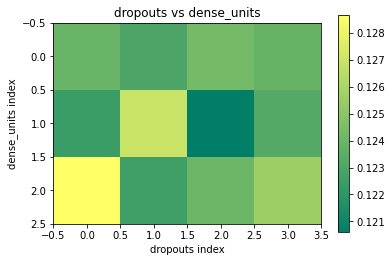

In [28]:
# # Using validation error
# visualize(d)

In [30]:
# %%capture capt

# vary_param = {'dense_units' : [[1000, 500, 100, 2], [800, 400, 80, 2], [500, 300, 50, 2]], 
#               'dropouts'    : [[0.7, 0.5, 0.2, 0], [0.5, 0.5, 0.2, 0],[0.5, 0.2, 0.2, 0], [0.2, 0.2, 0.2, 0]]
#              }


# d = vary_cfl_parameters(vary_param)

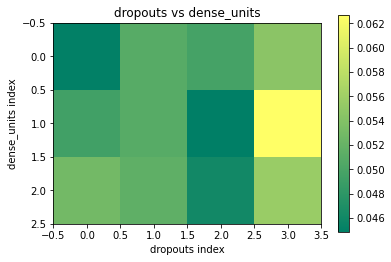

In [31]:
# # Using distribution error
# visualize(d)